# Model Selection

#### 1. Imports

In [1]:
import pandas as pd
import numpy as np
import joblib

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

#### 2. Load Processed Data

In [2]:
train_df = pd.read_csv("../data/processed/train_processed.csv")
test_df = pd.read_csv("../data/processed/test_processed.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (12192, 165)
Test shape: (3048, 165)


#### 3. Separate X and y

In [3]:
X_train = train_df.drop(columns=["selling_price"])
y_train = train_df["selling_price"]

X_test = test_df.drop(columns=["selling_price"])
y_test = test_df["selling_price"]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (12192, 164)
X_test: (3048, 164)
y_train: (12192,)
y_test: (3048,)


# Creating Different Models

#### 1. BaseLine

In [ ]:
models = {
    "Linear Regression": LinearRegression(),

    "Ridge": Ridge(alpha=1.0),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )
}

#### 2. Train and evaluate

Result List

In [5]:
results = []
trained_models = {}

Training the models

In [6]:
for name, model in models.items():

    print(f"Training {name}...")

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)

    rmse = np.sqrt(
        mean_squared_error(y_test, predictions)
    )

    r2 = r2_score(y_test, predictions)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    trained_models[name] = model

Training Linear Regression...
Training Ridge...
Training Random Forest...
Training Gradient Boosting...
Training Extra Trees...


#### 3. Comparision Table

In [7]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="MAE"
)

results_df

,Model,MAE,RMSE,R2
2,Random Forest,107402.399161,586434.524873,0.733774
4,Extra Trees,110553.213091,604252.012535,0.717351
3,Gradient Boosting,114704.876909,593191.242187,0.727604
0,Linear Regression,182774.280424,802057.228197,0.502008
1,Ridge,183330.269977,786291.383689,0.521394


In [8]:
results_display = results_df.copy()

results_display["MAE"] = results_display["MAE"].round(2)
results_display["RMSE"] = results_display["RMSE"].round(2)
results_display["R2"] = results_display["R2"].round(4)

results_display

,Model,MAE,RMSE,R2
2,Random Forest,107402.40,586434.52,0.7338
4,Extra Trees,110553.21,604252.01,0.7174
3,Gradient Boosting,114704.88,593191.24,0.7276
0,Linear Regression,182774.28,802057.23,0.5020
1,Ridge,183330.27,786291.38,0.5214


#### 4. Understand the metrics

#### MAE
** Mean Absolute Error

If:

MAE = ₹1,20,000

it means the model's prediction is off by approximately ₹1.2 lakh on average.

For our application, this is probably the most intuitive metric.

#### RMSE

** RMSE penalizes large errors more heavily. 

For example:

Actual       Prediction
₹5L          ₹5.5L
₹7L          ₹7.2L
₹40L         ₹25L    ← huge error

RMSE will punish that ₹15L error much more than MAE.

R²

R² measures how much variation in the target is explained by the model.

For example:

R² = 0.85

roughly means the model explains about 85% of the variance in the target on the test data.

Higher is generally better.

#### 5. Visualize model comparison

MAE

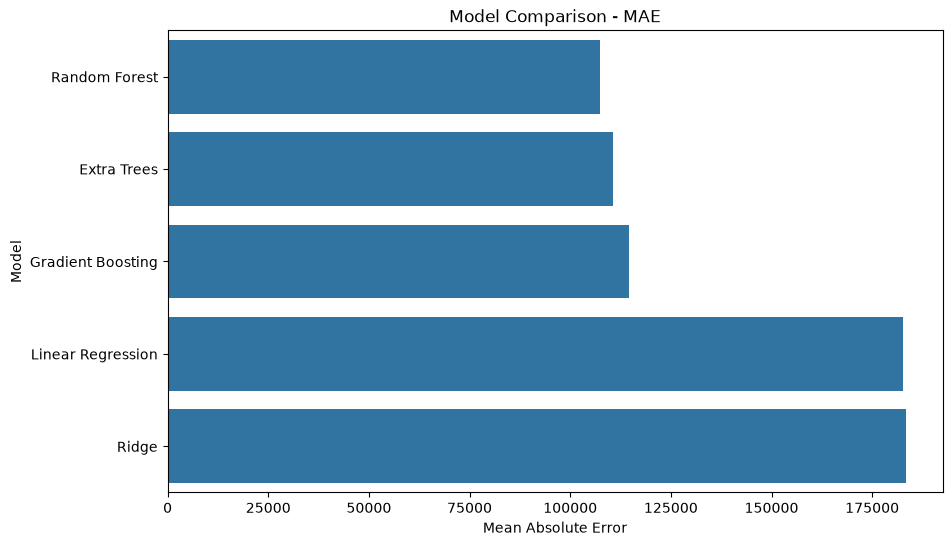

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x="MAE",
    y="Model"
)

plt.title("Model Comparison - MAE")
plt.xlabel("Mean Absolute Error")
plt.ylabel("Model")

plt.show()

R²

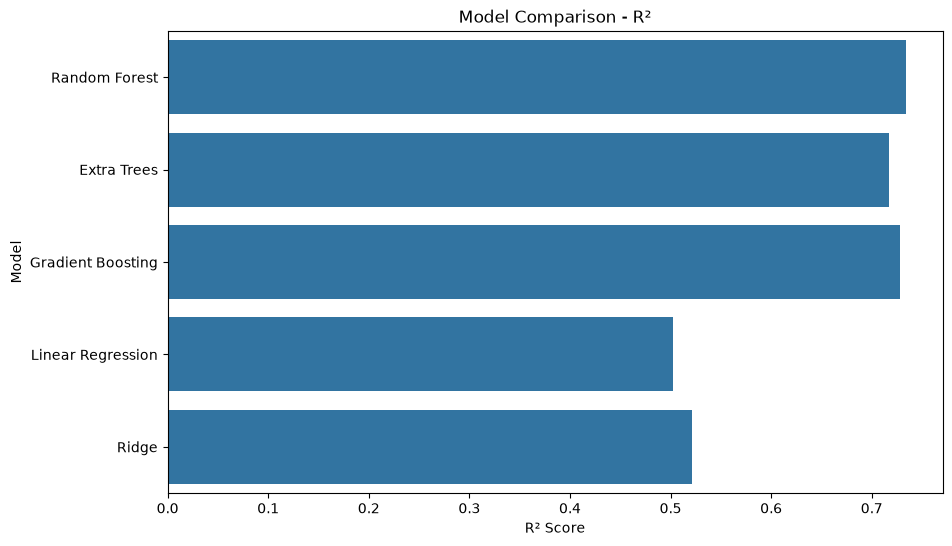

In [10]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x="R2",
    y="Model"
)

plt.title("Model Comparison - R²")
plt.xlabel("R² Score")
plt.ylabel("Model")

plt.show()

#### 6. Select the best Model

In [12]:
best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[best_model_name]

print("Best Model:", best_model_name)

Best Model: Random Forest


#### 7. Look at actual vs predicted

In [13]:
best_predictions = best_model.predict(X_test)

In [14]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": best_predictions
})

comparison.head(20)

,Actual Price,Predicted Price
0,650000,5.516900e+05
1,165000,1.995967e+05
2,250000,2.916506e+05
3,1200000,9.539133e+05
4,745000,8.013717e+05
5,395000,4.517589e+05
6,610000,6.003267e+05
7,480000,4.303702e+05
8,789000,6.930633e+05
9,200000,2.026208e+05


#### 9. Actual vs Predicted graph

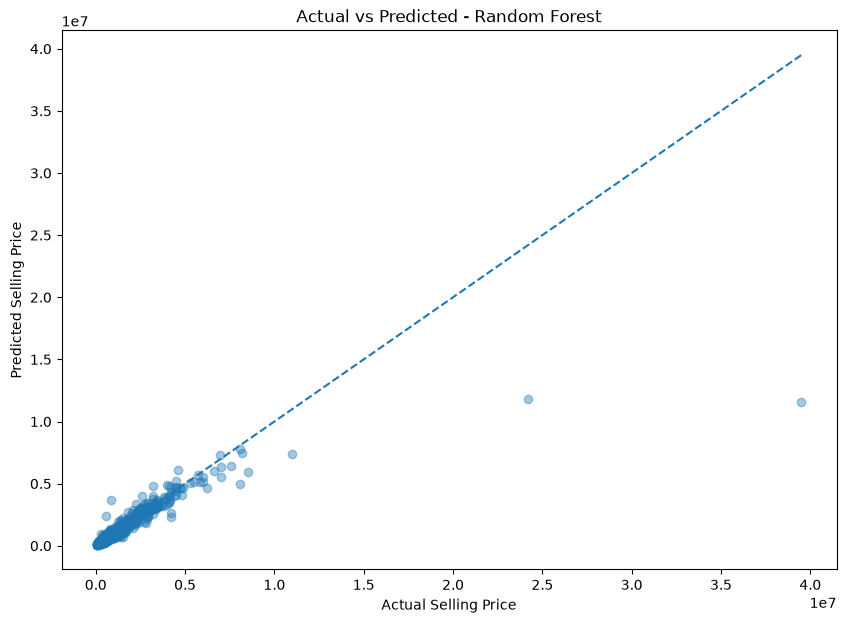

In [15]:
plt.figure(figsize=(10, 7))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.4
)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title(f"Actual vs Predicted - {best_model_name}")

min_price = min(y_test.min(), best_predictions.min())
max_price = max(y_test.max(), best_predictions.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.show()

#### 10. Analyze prediction errors

In [17]:
comparison["Error"] = (
    comparison["Predicted Price"]
    - comparison["Actual Price"]
)

comparison["Absolute Error"] = (
    comparison["Error"].abs()
)

comparison.sort_values(
    by="Absolute Error",
    ascending=False
).head(20)

,Actual Price,Predicted Price,Error,Absolute Error
538,39500000,1.159361e+07,-2.790639e+07,2.790639e+07
2518,24200000,1.184162e+07,-1.235838e+07,1.235838e+07
1319,11000000,7.353307e+06,-3.646693e+06,3.646693e+06
718,8100000,4.947833e+06,-3.152167e+06,3.152167e+06
858,875000,3.647557e+06,2.772557e+06,2.772557e+06
1410,8500000,5.962290e+06,-2.537710e+06,2.537710e+06
2471,4200000,2.306757e+06,-1.893243e+06,1.893243e+06
1910,595000,2.414010e+06,1.819010e+06,1.819010e+06
3044,3200000,4.815694e+06,1.615694e+06,1.615694e+06
2404,6200000,4.612341e+06,-1.587659e+06,1.587659e+06


#### 11. Check performance by price range

In [19]:
comparison["Price Range"] = pd.cut(
    comparison["Actual Price"],
    bins=[
        0,
        300000,
        600000,
        1000000,
        2000000,
        np.inf
    ],
    labels=[
        "Below 3L",
        "3L-6L",
        "6L-10L",
        "10L-20L",
        "Above 20L"
    ]
)

range_performance = (
    comparison
    .groupby("Price Range", observed=True)["Absolute Error"]
    .agg(["count", "mean", "median"])
)

range_performance

,count,mean,median
Price Range,,,
Below 3L,445,43686.896878,34527.361111
3L-6L,1289,60176.706080,44715.000000
6L-10L,813,84645.020239,62797.777778
10L-20L,347,162844.491766,122254.444444
Above 20L,154,682017.073361,261966.666667


#### 12. Feature importance

In [20]:
if hasattr(best_model, "feature_importances_"):

    feature_importance = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": best_model.feature_importances_
    })

    feature_importance = feature_importance.sort_values(
        by="Importance",
        ascending=False
    )

    feature_importance.head(20)

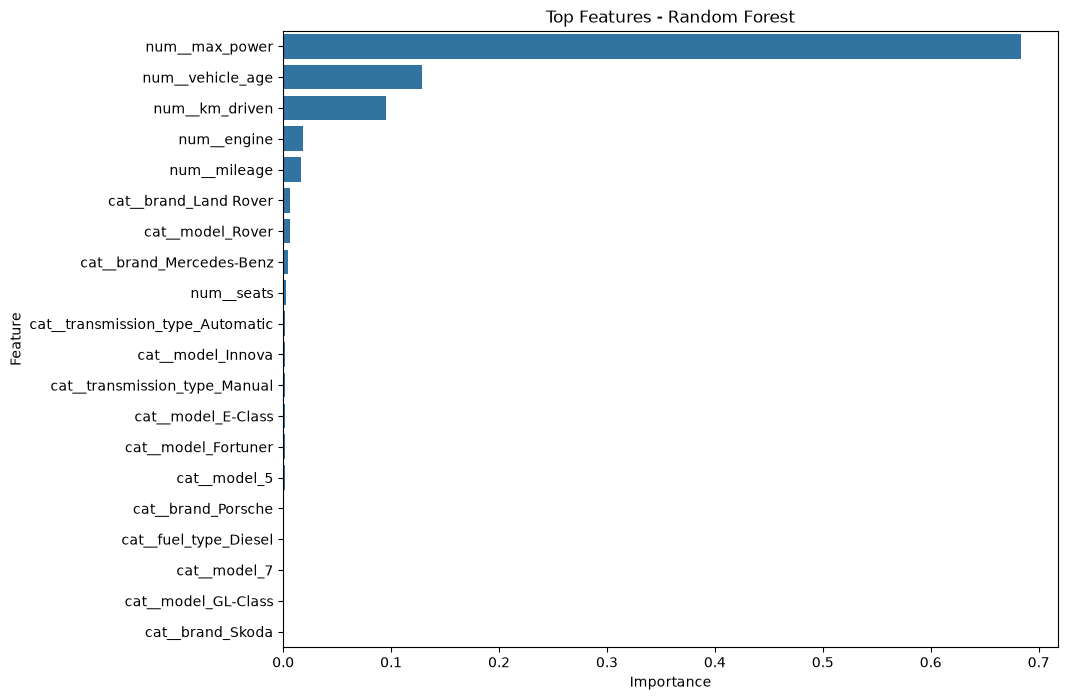

In [21]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=feature_importance.head(20),
    x="Importance",
    y="Feature"
)

plt.title(f"Top Features - {best_model_name}")

plt.show()

#### 13. Save the best Model

In [22]:
joblib.dump(
    best_model,
    "../models/best_model.pkl"
)

print(
    f"{best_model_name} saved successfully."
)

Random Forest saved successfully.
